<a href="https://colab.research.google.com/github/Kausharalam7/Data-Science/blob/main/Hosue_Price_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
data=pd.read_csv("train.csv")

In [ ]:
data.shape

(1460, 81)

In [ ]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
data.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [ ]:
missing=data.isnull().sum()
print(missing[missing>0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


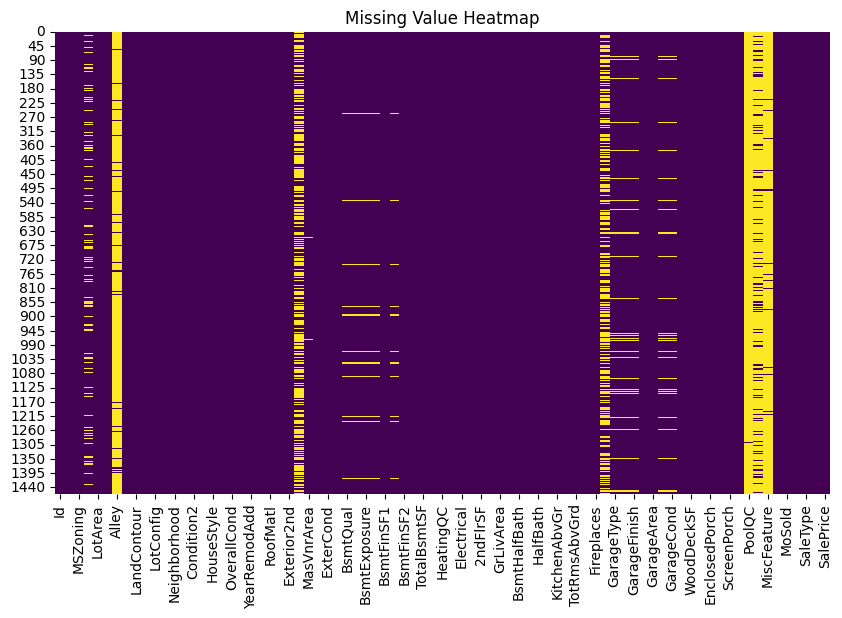

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

Handle Missing Values

In [ ]:
data['LotFrontage'] = data['LotFrontage'].fillna(data['LotFrontage'].median())
data['GarageType']  = data['GarageType'].fillna('None')
data['MasVnrType']  = data['MasVnrType'].fillna('None')
data['MasVnrArea']  = data['MasVnrArea'].fillna(0)

data = data.drop(columns=['Alley', 'PoolQC', 'Fence', 'MiscFeature'], errors='ignore')

In [ ]:
missing=data.isnull().sum()
print(missing[missing>0])

BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
FireplaceQu     690
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64


In [ ]:
data['BsmtQual'].unique()

array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

In [ ]:
basement_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in basement_cols:
    data[col] = data[col].fillna('NoBasement')

garage_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
for col in garage_cols:
    data[col] = data[col].fillna('NoGarage')

# Garage year built(numeric)
data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)
# or u can do df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].median())


data['FireplaceQu'] = data['FireplaceQu'].fillna('NoFireplace')


data['Electrical'] = data['Electrical'].fillna(data['Electrical'].mode()[0])


In [ ]:
missing=data.isnull().sum()
print(missing[missing>0])

Series([], dtype: int64)


Handle Outliers (using IQR for SalePrice)

In [ ]:
print(data['SalePrice'])

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64


In [ ]:
Q1 = data['SalePrice'].quantile(0.25)
Q3 = data['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data = data[(data['SalePrice'] >= lower) & (data['SalePrice'] <= upper)]
print(data['SalePrice'])

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1399, dtype: int64


Feature Engineering

In [ ]:
data['PricePerSqFt'] = data['SalePrice'] / data['GrLivArea']
data['HouseAge'] = 2025 - data['YearBuilt']
print(data['PricePerSqFt'])
print(data['HouseAge'])

0       121.929825
1       143.819334
2       125.139978
3        81.537566
4       113.739763
           ...    
1455    106.253795
1456    101.302460
1457    113.888889
1458    131.841373
1459    117.436306
Name: PricePerSqFt, Length: 1399, dtype: float64
0        22
1        49
2        24
3       110
4        25
       ... 
1455     26
1456     47
1457     84
1458     75
1459     60
Name: HouseAge, Length: 1399, dtype: int64


In [ ]:
data['MSSubClass'] = data['MSSubClass'].astype(str)

Encode Categorical Variables

In [ ]:
categorical = data.select_dtypes(include='object').columns
data= pd.get_dummies(data, columns=categorical, drop_first=True)

print("Data after encoding:", data.shape)

Data after encoding: (1399, 263)



Top correlated features:
 SalePrice       1.000000
OverallQual     0.784294
GrLivArea       0.661325
GarageCars      0.628013
GarageArea      0.607230
ExterQual_Gd    0.588472
FullBath        0.577369
YearBuilt       0.564558
TotalBsmtSF     0.543508
YearRemodAdd    0.541161
Name: SalePrice, dtype: float64


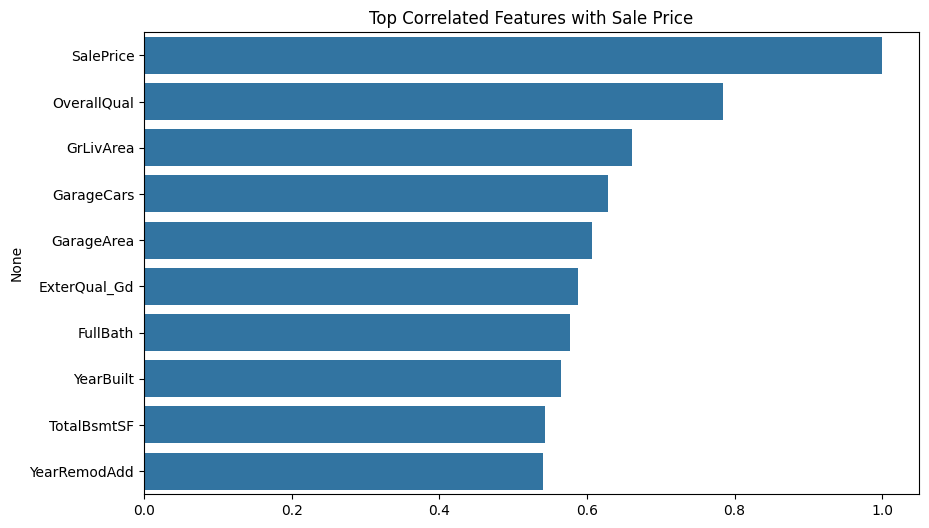

In [ ]:
plt.figure(figsize=(10, 6))
corr = data.corr()['SalePrice'].sort_values(ascending=False)
print("\nTop correlated features:\n", corr.head(10))
sns.barplot(x=corr.head(10).values, y=corr.head(10).index)
plt.title("Top Correlated Features with Sale Price")
plt.savefig('correlated.png')
plt.show()

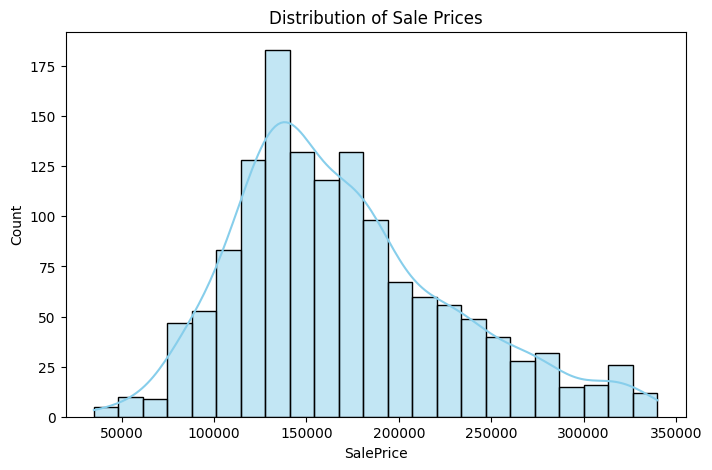

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data['SalePrice'], kde=True, color='skyblue')
plt.title("Distribution of Sale Prices")
plt.savefig('distribution.png')
plt.show()

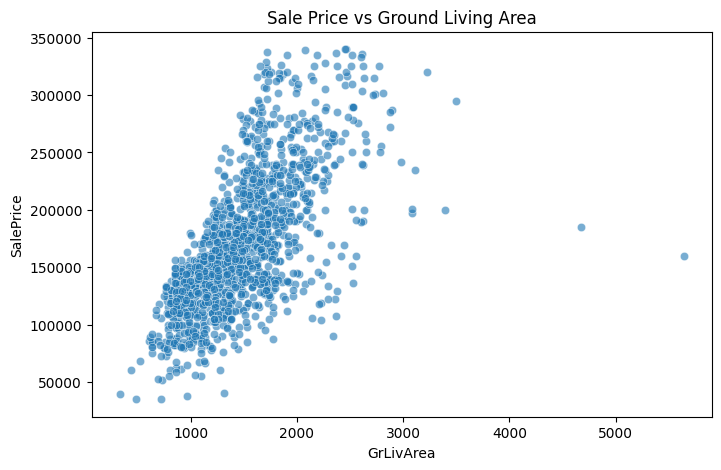

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=data, alpha=0.6)
plt.title("Sale Price vs Ground Living Area")
plt.savefig('glivearea.png')
plt.show()

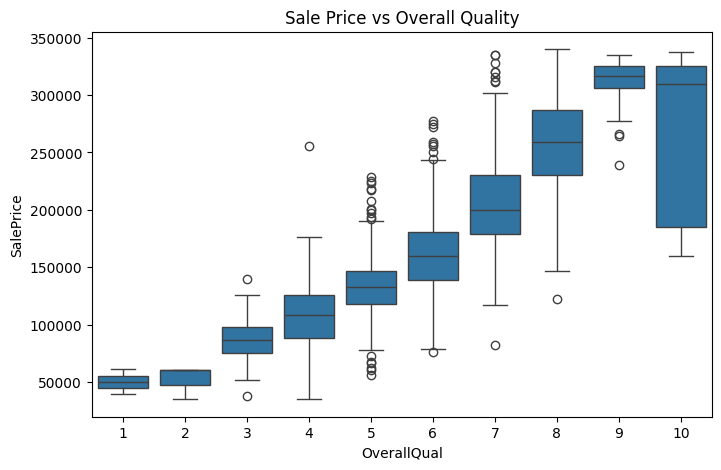

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='OverallQual', y='SalePrice', data=data)
plt.title("Sale Price vs Overall Quality")
plt.savefig('boxplot.png')
plt.show()

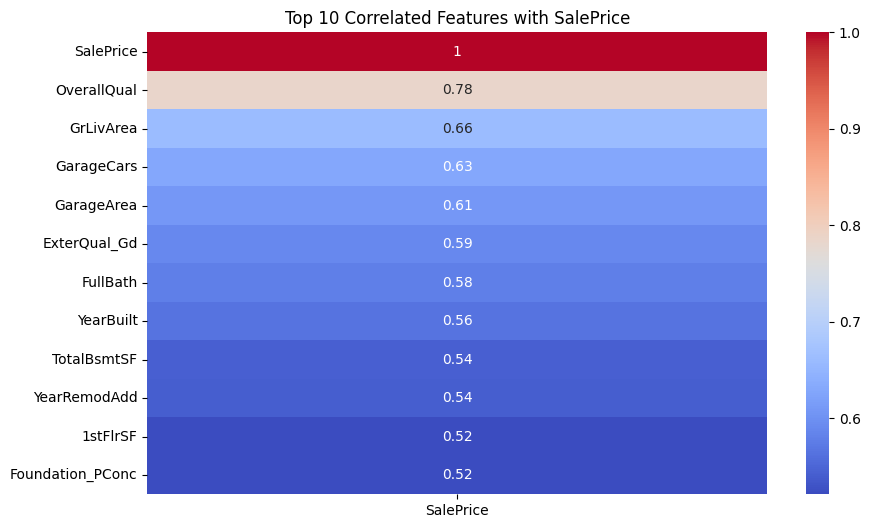

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr().nlargest(12, 'SalePrice')[['SalePrice']], annot=True, cmap='coolwarm')
plt.title("Top 10 Correlated Features with SalePrice")
plt.savefig('heatmap.png')
plt.show()

Linear Regression

In [ ]:
features = ['GrLivArea', 'OverallQual', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'HouseAge']
X = data[features]
y = data['SalePrice']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [ ]:
print("\n--- Model Performance ---")
print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")


--- Model Performance ---
R² Score: 0.804
Mean Absolute Error: 18424.69
Root Mean Squared Error: 24981.53


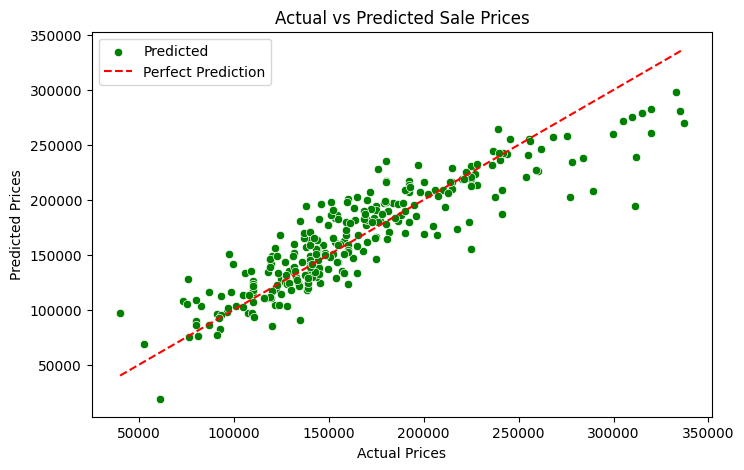

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, color='green', label='Predicted')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Sale Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Perfect Prediction')
plt.legend()
plt.savefig('prediction.png')
plt.show()

In [ ]:
data.to_csv("cleaned_real_estate_data.csv", index=False)
print("Cleaned data saved as 'cleaned_real_estate_data.csv'")

Cleaned data saved as 'cleaned_real_estate_data.csv'
